<a href="https://colab.research.google.com/github/eduardozurek/ia/blob/main/_007_aprendizaje_supervisado/_004_ROC_de_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


                 1. GENERACIÓN DEL CONJUNTO DE DATOS                  
Número total de muestras : 200
Muestras de entrenamiento: 120
Muestras de prueba        : 80

Clase 0 en prueba: 42
Clase 1 en prueba: 38


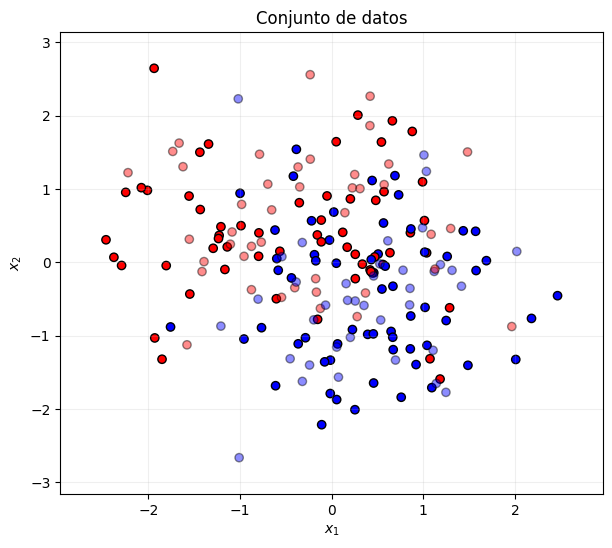


                  2. ENTRENAMIENTO DEL RANDOM FOREST                  
Modelo entrenado correctamente.
Número de árboles: 10

               3. CLASIFICACIÓN DEL CONJUNTO DE PRUEBA                
╭────────┬──────────────┬──────────────╮
│        │   Predicho 0 │   Predicho 1 │
├────────┼──────────────┼──────────────┤
│ Real 0 │           27 │           15 │
├────────┼──────────────┼──────────────┤
│ Real 1 │            9 │           29 │
╰────────┴──────────────┴──────────────╯

Interpretación:
TN = 27  → verdaderos negativos
FP = 15  → falsos positivos
FN =  9  → falsos negativos
TP = 29  → verdaderos positivos

Accuracy = 0.7000


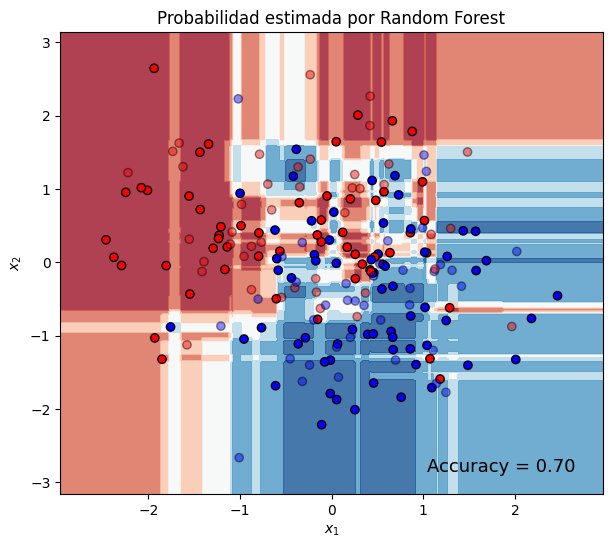


          4. PROBABILIDADES ESTIMADAS PARA LA CLASE POSITIVA          
╭───────────┬────────────────┬──────────────╮
│   Muestra │   Clase real y │   P(y=1 | x) │
├───────────┼────────────────┼──────────────┤
│         0 │            1.0 │        0.700 │
├───────────┼────────────────┼──────────────┤
│         1 │            0.0 │        0.500 │
├───────────┼────────────────┼──────────────┤
│         2 │            0.0 │        0.700 │
├───────────┼────────────────┼──────────────┤
│         3 │            1.0 │        0.700 │
├───────────┼────────────────┼──────────────┤
│         4 │            0.0 │        0.400 │
├───────────┼────────────────┼──────────────┤
│         5 │            1.0 │        0.600 │
├───────────┼────────────────┼──────────────┤
│         6 │            1.0 │        0.900 │
├───────────┼────────────────┼──────────────┤
│         7 │            0.0 │        0.200 │
├───────────┼────────────────┼──────────────┤
│         8 │            1.0 │        0.800 │
├───────

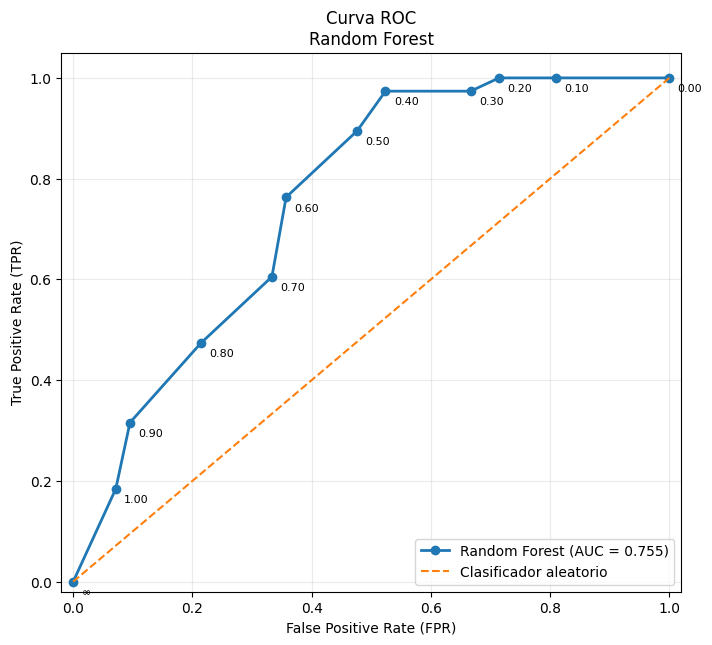

In [1]:
# ============================================================
# RANDOM FOREST + CONSTRUCCIÓN PASO A PASO DE LA CURVA ROC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from tabulate import tabulate

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier


# ============================================================
# Funciones auxiliares para mejorar la presentación
# ============================================================

def titulo(texto):
    print("\n" + "=" * 70)
    print(texto.center(70))
    print("=" * 70)


def subtitulo(texto):
    print("\n" + "-" * 70)
    print(texto)
    print("-" * 70)


# ============================================================
# 1. GENERACIÓN DE LOS DATOS
# ============================================================

titulo("1. GENERACIÓN DEL CONJUNTO DE DATOS")

numero_de_muestras = 200

X, y = make_moons(
    n_samples=numero_de_muestras,
    noise=0.8,
    random_state=13
)

X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

print(f"Número total de muestras : {len(X)}")
print(f"Muestras de entrenamiento: {len(X_train)}")
print(f"Muestras de prueba        : {len(X_test)}")

print(f"\nClase 0 en prueba: {np.sum(y_test == 0)}")
print(f"Clase 1 en prueba: {np.sum(y_test == 1)}")


# ============================================================
# 2. VISUALIZACIÓN DE LOS DATOS
# ============================================================

cm = plt.cm.RdBu
cm_bright = ListedColormap(["#FF0000", "#0000FF"])

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

h = 0.02

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

plt.figure(figsize=(7, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap=cm_bright,
    edgecolors="k",
    label="Entrenamiento"
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap=cm_bright,
    alpha=0.45,
    edgecolors="k",
    label="Prueba"
)

plt.title("Conjunto de datos")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid(alpha=0.2)
plt.show()


# ============================================================
# 3. ENTRENAMIENTO DEL RANDOM FOREST
# ============================================================

titulo("2. ENTRENAMIENTO DEL RANDOM FOREST")

clf = RandomForestClassifier(
    n_estimators=10,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,

    # En versiones actuales de sklearn se usa "sqrt"
    # en lugar de "auto".
    max_features="sqrt",

    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,

    # Para obtener siempre el mismo resultado
    random_state=42,

    verbose=0,
    warm_start=False,
    ccp_alpha=0.0,
    max_samples=None
)

clf.fit(X_train, y_train)

print("Modelo entrenado correctamente.")
print(f"Número de árboles: {clf.n_estimators}")


# ============================================================
# 4. PREDICCIONES CON UMBRAL NORMAL DE CLASIFICACIÓN
# ============================================================

titulo("3. CLASIFICACIÓN DEL CONJUNTO DE PRUEBA")

y_predict = clf.predict(X_test)

CM = confusion_matrix(y_test, y_predict)

TN, FP, FN, TP = CM.ravel()

tabla_cm = [
    [TN, FP],
    [FN, TP]
]

print(
    tabulate(
        tabla_cm,
        headers=["Predicho 0", "Predicho 1"],
        showindex=["Real 0", "Real 1"],
        tablefmt="rounded_grid"
    )
)

print("\nInterpretación:")

print(f"TN = {TN:2d}  → verdaderos negativos")
print(f"FP = {FP:2d}  → falsos positivos")
print(f"FN = {FN:2d}  → falsos negativos")
print(f"TP = {TP:2d}  → verdaderos positivos")

score = clf.score(X_test, y_test)

print(f"\nAccuracy = {score:.4f}")


# ============================================================
# 5. FRONTERA DE DECISIÓN
# ============================================================

Z = clf.predict_proba(
    np.c_[xx.ravel(), yy.ravel()]
)[:, 1]

Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 6))

plt.contourf(
    xx,
    yy,
    Z,
    cmap=cm,
    alpha=0.8
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    cmap=cm_bright,
    edgecolors="k"
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap=cm_bright,
    edgecolors="k",
    alpha=0.45
)

plt.title("Probabilidad estimada por Random Forest")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.text(
    xx.max() - 0.3,
    yy.min() + 0.3,
    f"Accuracy = {score:.2f}",
    size=13,
    horizontalalignment="right"
)

plt.show()


# ============================================================
# 6. PROBABILIDADES PARA CONSTRUIR LA ROC
# ============================================================

titulo("4. PROBABILIDADES ESTIMADAS PARA LA CLASE POSITIVA")

# Probabilidad de pertenecer a la clase 1
y_prob = clf.predict_proba(X_test)[:, 1]

datos_probabilidades = []

for i in range(len(y_test)):
    datos_probabilidades.append([
        i,
        y_test[i],
        y_prob[i]
    ])

print(
    tabulate(
        datos_probabilidades,
        headers=[
            "Muestra",
            "Clase real y",
            "P(y=1 | x)"
        ],
        floatfmt=("", "", ".3f"),
        tablefmt="rounded_grid"
    )
)


# ============================================================
# 7. ORDENAR LAS PROBABILIDADES
# ============================================================

titulo("5. ORDENAMIENTO POR PROBABILIDAD")

# Para entender ROC es más intuitivo ordenar
# de mayor a menor probabilidad.
indices = np.argsort(y_prob)[::-1]

tabla_ordenada = []

for posicion, i in enumerate(indices):

    tabla_ordenada.append([
        posicion + 1,
        i,
        y_prob[i],
        y_test[i]
    ])

print(
    tabulate(
        tabla_ordenada,
        headers=[
            "Orden",
            "Muestra",
            "Probabilidad",
            "Clase real"
        ],
        floatfmt=("", "", ".3f", ""),
        tablefmt="rounded_grid"
    )
)


# ============================================================
# 8. VALORES ÚNICOS QUE PUEDEN USARSE COMO UMBRAL
# ============================================================

titulo("6. UMBRALES DE DECISIÓN")

umbrales = np.sort(
    np.unique(y_prob)
)[::-1]

# np.inf representa el caso inicial:
# ninguna muestra se considera positiva.
umbrales = np.insert(umbrales, 0, np.inf)

print("Umbrales que se evaluarán:\n")

for i, u in enumerate(umbrales):

    if np.isinf(u):
        print(f"t[{i:2d}] = ∞")
    else:
        print(f"t[{i:2d}] = {u:.3f}")


# ============================================================
# 9. CONSTRUCCIÓN MANUAL DE LA CURVA ROC
# ============================================================

titulo("7. CÁLCULO MANUAL DE LOS PUNTOS DE LA CURVA ROC")

P = np.sum(y_test == 1)
N = np.sum(y_test == 0)

print(f"Positivos reales P = {P}")
print(f"Negativos reales N = {N}")

print("\nPara cada umbral t se aplica:")
print()
print("        ŷ = 1   si   P(y=1|x) >= t")
print("        ŷ = 0   si   P(y=1|x) <  t")

print("\nDespués calculamos:")

print()
print("              TP")
print("    TPR = -----------")
print("           TP + FN")

print()
print("              FP")
print("    FPR = -----------")
print("           FP + TN")


roc_manual = []

for k, threshold in enumerate(umbrales):

    # --------------------------------------------------------
    # Clasificación utilizando el umbral actual
    # --------------------------------------------------------

    y_pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    # --------------------------------------------------------
    # Matriz de confusión
    # --------------------------------------------------------

    TN = np.sum(
        (y_test == 0) &
        (y_pred_threshold == 0)
    )

    FP = np.sum(
        (y_test == 0) &
        (y_pred_threshold == 1)
    )

    FN = np.sum(
        (y_test == 1) &
        (y_pred_threshold == 0)
    )

    TP = np.sum(
        (y_test == 1) &
        (y_pred_threshold == 1)
    )

    # --------------------------------------------------------
    # Coordenadas ROC
    # --------------------------------------------------------

    TPR = TP / P
    FPR = FP / N

    roc_manual.append([
        threshold,
        TN,
        FP,
        FN,
        TP,
        FPR,
        TPR
    ])


# ============================================================
# 10. TABLA COMPLETA ROC
# ============================================================

subtitulo("Tabla resumen del cálculo")

tabla_impresion = []

for fila in roc_manual:

    threshold, TN, FP, FN, TP, FPR, TPR = fila

    if np.isinf(threshold):
        threshold_text = "∞"
    else:
        threshold_text = f"{threshold:.3f}"

    tabla_impresion.append([
        threshold_text,
        TN,
        FP,
        FN,
        TP,
        f"{FPR:.3f}",
        f"{TPR:.3f}"
    ])

print(
    tabulate(
        tabla_impresion,
        headers=[
            "Umbral",
            "TN",
            "FP",
            "FN",
            "TP",
            "FPR",
            "TPR"
        ],
        tablefmt="rounded_grid"
    )
)


# ============================================================
# 11. MOSTRAR EL CÁLCULO PASO A PASO
# ============================================================

titulo("8. DESARROLLO PASO A PASO")

for paso, fila in enumerate(roc_manual):

    threshold, TN, FP, FN, TP, FPR, TPR = fila

    if np.isinf(threshold):
        threshold_text = "∞"
    else:
        threshold_text = f"{threshold:.3f}"

    print()
    print(f"PASO {paso}")
    print("-" * 50)

    print(f"Umbral t = {threshold_text}")

    print(f"\nTN = {TN}")
    print(f"FP = {FP}")
    print(f"FN = {FN}")
    print(f"TP = {TP}")

    print("\nCálculo de TPR:")

    print(
        f"TPR = TP / (TP + FN)"
        f" = {TP} / ({TP} + {FN})"
        f" = {TP}/{P}"
        f" = {TPR:.3f}"
    )

    print("\nCálculo de FPR:")

    print(
        f"FPR = FP / (FP + TN)"
        f" = {FP} / ({FP} + {TN})"
        f" = {FP}/{N}"
        f" = {FPR:.3f}"
    )

    print(
        f"\nPunto ROC → "
        f"(FPR, TPR) = ({FPR:.3f}, {TPR:.3f})"
    )


# ============================================================
# 12. RESULTADOS DE SCIKIT-LEARN
# ============================================================

titulo("9. COMPARACIÓN CON sklearn.metrics.roc_curve")

fpr_sklearn, tpr_sklearn, thresholds_sklearn = roc_curve(
    y_test,
    y_prob,

    # Muy importante para fines didácticos:
    drop_intermediate=False
)

tabla_sklearn = []

for threshold, fpr, tpr in zip(
    thresholds_sklearn,
    fpr_sklearn,
    tpr_sklearn
):

    if np.isinf(threshold):
        threshold_text = "∞"
    else:
        threshold_text = f"{threshold:.3f}"

    tabla_sklearn.append([
        threshold_text,
        f"{fpr:.3f}",
        f"{tpr:.3f}"
    ])

print(
    tabulate(
        tabla_sklearn,
        headers=[
            "Umbral",
            "FPR sklearn",
            "TPR sklearn"
        ],
        tablefmt="rounded_grid"
    )
)


# ============================================================
# 13. AUC
# ============================================================

titulo("10. CÁLCULO DEL ÁREA BAJO LA CURVA ROC")

roc_auc = auc(
    fpr_sklearn,
    tpr_sklearn
)

print("El AUC se obtiene integrando numéricamente")
print("el área bajo la curva ROC mediante trapecios.\n")

print(f"AUC = {roc_auc:.4f}")


# ============================================================
# 14. GRÁFICA ROC
# ============================================================

plt.figure(figsize=(8, 7))

plt.plot(
    fpr_sklearn,
    tpr_sklearn,
    marker="o",
    linewidth=2,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

# Clasificador aleatorio
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Clasificador aleatorio"
)

# Identificar cada punto con su umbral
for fpr, tpr, threshold in zip(
    fpr_sklearn,
    tpr_sklearn,
    thresholds_sklearn
):

    if np.isinf(threshold):
        texto = "∞"
    else:
        texto = f"{threshold:.2f}"

    plt.annotate(
        texto,
        (fpr, tpr),
        xytext=(6, -10),
        textcoords="offset points",
        fontsize=8
    )

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")

plt.title(
    "Curva ROC\n"
    "Random Forest"
)

plt.grid(alpha=0.25)
plt.legend(loc="lower right")

plt.show()